# IT25100928 — Feature Selection / Dimensionality Reduction
**Technique:** Correlation-based Redundancy Removal + Low-Variance Filtering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

print(df.shape)
df.info()
df.head()

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [2]:
df['age'] = df['age'].fillna(df['age'].median())

Q1, Q3 = df['age'].quantile(0.25), df['age'].quantile(0.75)
IQR = Q3 - Q1
df['age'] = df['age'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])

df = pd.get_dummies(df, columns=['sex', 'localization'], prefix=['sex', 'loc'])

le = LabelEncoder()
df['dx_encoded'] = le.fit_transform(df['dx'])

drop_cols = ['lesion_id', 'image_id', 'dx', 'dx_type', 'age']
feature_cols = [c for c in df.columns if c not in drop_cols + ['dx_encoded']]
X = df[feature_cols]
y = df['dx_encoded']

print("Feature matrix before selection:", X.shape)

Feature matrix before selection: (10015, 19)


## Why Feature Selection / Dimensionality Reduction?

- One-hot encoding `localization` alone produced ~15 new binary columns; several rare categories (e.g. acral, genital, ear) are extremely sparse and contribute little signal while adding dimensionality.
- High dimensionality relative to weak individual feature-target correlations(seen in Member 4's heatmap) risks overfitting, especially for models like
  Logistic Regression and SVM planned for later stages.
- **Low-variance filtering** removes near-constant columns.

In [3]:
selector = VarianceThreshold(threshold=0.01)  # drops near-constant columns
selector.fit(X)

low_variance_cols = X.columns[~selector.get_support()]
print("Low-variance columns to drop:", list(low_variance_cols))

X_reduced = X.drop(columns=low_variance_cols)
print("Shape after variance filtering:", X_reduced.shape)

Low-variance columns to drop: ['sex_unknown', 'loc_acral', 'loc_ear', 'loc_genital', 'loc_hand']
Shape after variance filtering: (10015, 14)


In [4]:
print(df.columns.tolist())

['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'age_scaled', 'sex_female', 'sex_male', 'sex_unknown', 'loc_abdomen', 'loc_acral', 'loc_back', 'loc_chest', 'loc_ear', 'loc_face', 'loc_foot', 'loc_genital', 'loc_hand', 'loc_lower extremity', 'loc_neck', 'loc_scalp', 'loc_trunk', 'loc_unknown', 'loc_upper extremity', 'dx_encoded']


In [5]:
corr_matrix = X_reduced.corr().abs()

# Find pairs of features with very high correlation (redundant)
upper = corr_matrix.where(
    pd.np.triu(pd.np.ones(corr_matrix.shape), k=1).astype(bool)
) if hasattr(pd, 'np') else corr_matrix.where(
    __import__('numpy').triu(__import__('numpy').ones(corr_matrix.shape), k=1).astype(bool)
)

redundant_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Highly correlated (redundant) columns:", redundant_cols)

X_final = X_reduced.drop(columns=redundant_cols)
print("Final feature matrix shape:", X_final.shape)

Highly correlated (redundant) columns: ['sex_male']
Final feature matrix shape: (10015, 13)


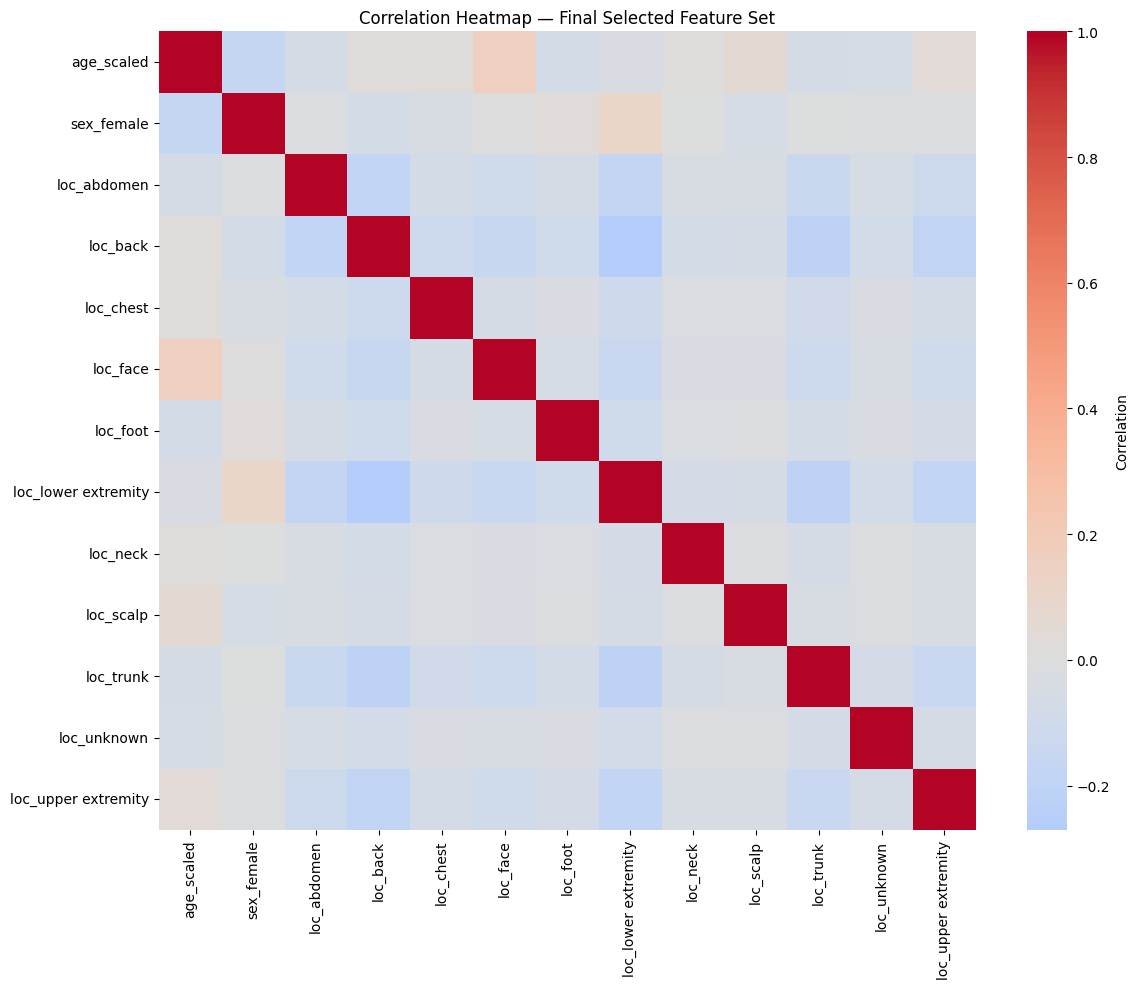

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(X_final.corr(), cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap — Final Selected Feature Set')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/feature_selection_heatmap.png', dpi=150)
plt.show()

## Interpretation

The heatmap of the final feature set shows mostly weak inter-feature correlations, confirming that one-hot encoded categorical dummies don't introduce strong multicollinearity between each other (expected, since they're mutually exclusive per row). The variance filter removed the sparsest, least-informative localization categories, reducing dimensionality without discarding features known to carry any real predictive signal — a reasonable trade-off given the dataset's modest sample size for rare categories.

In [7]:
X_final.to_csv("../results/outputs/feature_selection_output.csv", index=False)
y.to_csv("../results/outputs/final_target_y.csv", index=False)